# 03 - Phan tich kham pha du lieu (EDA)

Notebook nay dung de doc hieu du lieu ban hang sau buoc lam sach va data mart. Mach phan tich duoc sap xep theo thu tu:

1. Nap du lieu va kiem tra chat luong.
2. Tong quan KPI kinh doanh theo nam.
3. Xu huong theo thoi gian va mua vu.
4. Co cau doanh thu theo kenh ban hang va nhom san pham.
5. Phan tich khach hang/Pareto.
6. Tuong quan giua cac chi so.
7. Phan tich outlier de lap danh sach can kiem tra.
8. Tong hop nhan xet EDA.

# 0. Cai dat moi truong va nap du lieu

Buoc nay nap cac file output cua pipeline, doi ten cot ve tieng Viet khong dau de code ngan gon hon, va hien thi nhanh bang chat luong du lieu.

In [13]:
import site
import sys
import unicodedata
from pathlib import Path

USER_SITE = site.getusersitepackages()
if Path(USER_SITE).exists() and USER_SITE not in sys.path:
    sys.path.insert(0, USER_SITE)

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")

from src.config import CLEAN_DIR, MART_DIR
from src.pipeline import load_final_sales


def bo_dau_tieng_viet(text):
    """Chuyen chu co dau thanh khong dau de code de doc hon."""
    text = str(text).replace("?", "d").replace("?", "D")
    text = unicodedata.normalize("NFD", text)
    text = "".join(char for char in text if unicodedata.category(char) != "Mn")
    return " ".join(text.split())


def doi_ten_cot_khong_dau(bang_du_lieu):
    bang_du_lieu = bang_du_lieu.copy()
    bang_du_lieu.columns = [bo_dau_tieng_viet(cot) for cot in bang_du_lieu.columns]
    return bang_du_lieu


def dinh_dang_ty_vnd(series):
    return series / 1e9


chat_luong = doi_ten_cot_khong_dau(pd.read_csv(CLEAN_DIR / "data_quality_overview.csv"))
du_lieu_ban_hang = doi_ten_cot_khong_dau(load_final_sales())
tong_quan_nam = doi_ten_cot_khong_dau(pd.read_csv(MART_DIR / "mart_overview_year.csv"))
theo_thang = doi_ten_cot_khong_dau(pd.read_csv(MART_DIR / "mart_time_month.csv"))
theo_quy = doi_ten_cot_khong_dau(pd.read_csv(MART_DIR / "mart_time_quarter.csv"))
pareto_khach_hang = doi_ten_cot_khong_dau(pd.read_csv(MART_DIR / "mart_pareto_customer_group.csv"))

du_lieu_ban_hang["Ngay chung tu"] = pd.to_datetime(du_lieu_ban_hang["Ngay chung tu"], errors="coerce")

print(f"So dong: {du_lieu_ban_hang.shape[0]:,}")
print(f"So cot: {du_lieu_ban_hang.shape[1]:,}")
print(f"Khoang ngay: {du_lieu_ban_hang['Ngay chung tu'].min().date()} -> {du_lieu_ban_hang['Ngay chung tu'].max().date()}")
display(chat_luong)

So dong: 55,050
So cot: 38
Khoang ngay: 2023-01-01 -> 2026-05-28


,Bang,So dong,So cot,So o null,So dong duplicate toan dong,So dong duplicate theo co
0,raw_sales_2023_2025,34207,19,0,29,NaN
1,raw_sales_2026,20843,22,39475,14,NaN
2,raw_cost_2026,242,6,0,0,NaN
3,sales_2023_2025_clean,34207,29,68414,29,29.00
4,sales_2026_clean,20843,39,0,14,14.00
5,cost_2026_clean,242,6,0,0,NaN
6,sales_final,55050,38,5539,43,43.00


# 1. Kiem tra chat luong va pham vi du lieu

Muc tieu la xac nhan du lieu du de phan tich: khoang thoi gian, so dong theo nam, duplicate, null va cac cot tien quan trong.

In [2]:
bang_pham_vi = (
    du_lieu_ban_hang
    .groupby("Nam", dropna=False)
    .agg(
        Ngay_dau=("Ngay chung tu", "min"),
        Ngay_cuoi=("Ngay chung tu", "max"),
        So_dong=("Doanh thu thuan", "size"),
        So_chung_tu=("So chung tu", "nunique"),
        So_khach_hang=("Ma khach hang", "nunique"),
        So_san_pham=("Ma san pham", "nunique"),
        Doanh_thu=("Doanh thu thuan", "sum"),
        Loi_nhuan=("Loi nhuan", "sum"),
    )
    .reset_index()
)
bang_pham_vi["Bien_loi_nhuan"] = bang_pham_vi["Loi_nhuan"] / bang_pham_vi["Doanh_thu"]
display(bang_pham_vi)

null_theo_cot = (
    du_lieu_ban_hang.isna().sum()
    .rename("So_o_null")
    .reset_index()
    .rename(columns={"index": "Cot"})
)
null_theo_cot["Ty_le_null"] = null_theo_cot["So_o_null"] / len(du_lieu_ban_hang)
display(null_theo_cot[null_theo_cot["So_o_null"] > 0].sort_values("So_o_null", ascending=False).head(15))

,Nam,Ngay_dau,Ngay_cuoi,So_dong,So_chung_tu,So_khach_hang,So_san_pham,Doanh_thu,Loi_nhuan,Bien_loi_nhuan
0,2023,2023-01-01,2023-12-31,10443,7136,163,67,"38,154,695,993.00","8,763,674,472.08",0.23
1,2024,2024-01-01,2024-12-31,10553,7235,191,72,"39,930,169,808.00","9,359,486,280.00",0.23
2,2025,2025-01-02,2025-12-31,13211,7670,225,95,"40,816,618,384.81","9,758,773,664.00",0.24
3,2026,2026-01-01,2026-05-28,20843,13273,155,242,"18,727,782,269.37","7,244,223,491.37",0.39


,Cot,So_o_null,Ty_le_null
34,Bien loi nhuan,1893,0.03
35,Ty le chiet khau,1823,0.03
36,Ty le hoan tra,1823,0.03


# 2. Tong quan KPI theo nam

Buoc nay tra loi cau hoi: doanh thu, loi nhuan, bien loi nhuan va quy mo don hang thay doi nhu the nao qua cac nam. Luu y nam 2026 trong bo du lieu hien chi gom cac thang da co trong file nguon, nen khi so sanh YoY can doc nhu giai doan chua tron nam.

,Nam,Doanh thu ty VND,Loi nhuan ty VND,Bien loi nhuan,Tang truong doanh thu YoY,Tang truong loi nhuan YoY,Gia tri TB/don
0,2023,13.18,3.16,0.24,NaN,NaN,"5,011,523.91"
1,2024,20.07,4.30,0.21,0.52,0.36,"7,629,907.82"
2,2025,15.67,3.69,0.24,-0.22,-0.14,"5,878,436.96"
3,2026,18.73,7.24,0.39,0.19,0.96,"1,410,968.30"


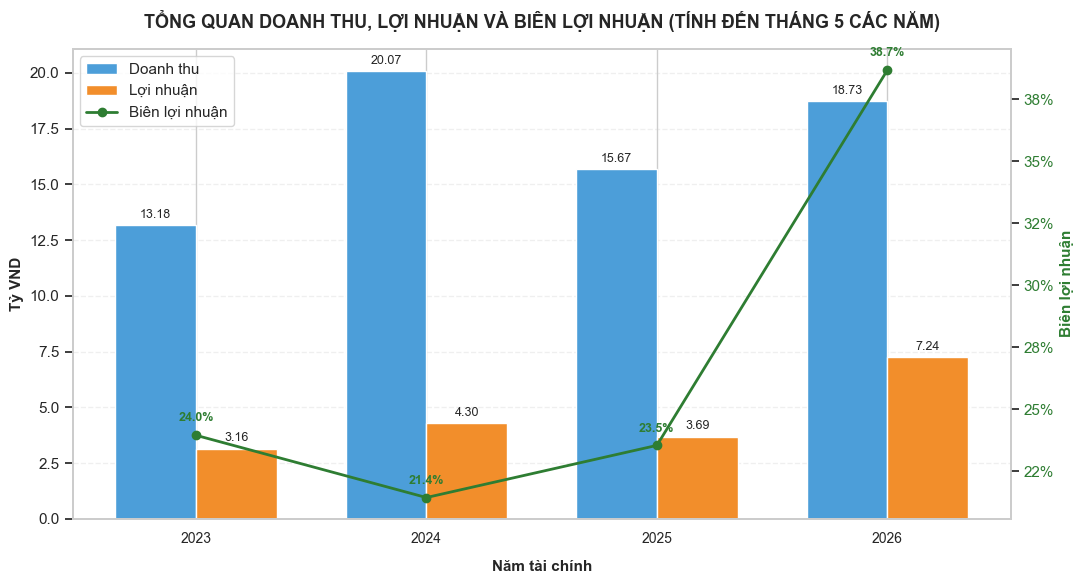

In [12]:
du_lieu_ytd = du_lieu_ban_hang[
    du_lieu_ban_hang["Ngay chung tu"].dt.month <= 5
].copy()
tong_quan_nam_ytd = (
    du_lieu_ytd.groupby("Nam", dropna=False)
    .agg(
        Doanh_thu_thuan=("Doanh thu thuan", "sum"),
        Loi_nhuan=("Loi nhuan", "sum"),
        So_don_hang=("So chung tu", "nunique"),
        So_khach_hang=("Ma khach hang", "nunique"),
        So_san_pham=("Ma san pham", "nunique"),
    )
    .reset_index()
)
tong_quan_nam_ytd["Bien loi nhuan"] = (
    tong_quan_nam_ytd["Loi_nhuan"] / tong_quan_nam_ytd["Doanh_thu_thuan"]
)
tong_quan_nam_ytd["Gia tri TB/don"] = (
    tong_quan_nam_ytd["Doanh_thu_thuan"] / tong_quan_nam_ytd["So_don_hang"]
)

kpi_nam = tong_quan_nam_ytd.sort_values("Nam").copy()

kpi_nam["Doanh thu số tỷ"] = kpi_nam["Doanh_thu_thuan"] / 1e9
kpi_nam["Loi nhuan số tỷ"] = kpi_nam["Loi_nhuan"] / 1e9
kpi_nam["Tang truong doanh thu YoY"] = kpi_nam["Doanh_thu_thuan"].pct_change()
kpi_nam["Tang truong loi nhuan YoY"] = kpi_nam["Loi_nhuan"].pct_change()

kpi_nam["Doanh thu ty VND"] = dinh_dang_ty_vnd(kpi_nam["Doanh_thu_thuan"])
kpi_nam["Loi nhuan ty VND"] = dinh_dang_ty_vnd(kpi_nam["Loi_nhuan"])

cot_kpi = [
    "Nam",
    "Doanh thu ty VND",
    "Loi nhuan ty VND",
    "Bien loi nhuan",
    "Tang truong doanh thu YoY",
    "Tang truong loi nhuan YoY",
    "So don hang",
    "So khach hang",
    "So san pham",
    "Gia tri TB/don",
]
cot_kpi = [cot for cot in cot_kpi if cot in kpi_nam.columns]
display(kpi_nam[cot_kpi])


cac_nam = kpi_nam["Nam"].astype(str).tolist()
x = np.arange(len(cac_nam))
width = 0.35 

fig, ax1 = plt.subplots(figsize=(11, 6))

rects1 = ax1.bar(
    x - width / 2,
    kpi_nam["Doanh thu số tỷ"],
    width,
    color="#4C9ED9",
    label="Doanh thu",
)

rects2 = ax1.bar(
    x + width / 2,
    kpi_nam["Loi nhuan số tỷ"],
    width,
    color="#F28E2B",
    label="Lợi nhuận",
)
ax1.set_xlabel("Năm tài chính", fontsize=11, fontweight="bold", labelpad=10)
ax1.set_ylabel("Tỷ VND", fontsize=11, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(cac_nam, fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax1.bar_label(rects1, padding=3, fmt="%.2f", fontsize=9)
ax1.bar_label(rects2, padding=3, fmt="%.2f", fontsize=9)

ax2 = ax1.twinx()
rects3 = ax2.plot(
    cac_nam,
    kpi_nam["Bien loi nhuan"],
    color="#2E7D32",
    marker="o",
    linewidth=2,
    markersize=6,
    label="Biên lợi nhuận",
)

ax2.set_ylabel("Biên lợi nhuận", fontsize=11, fontweight="bold", color="#2E7D32")
ax2.tick_params(axis="y", labelcolor="#2E7D32")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: f"{val:.0%}"))
ax2.grid(False)

for i, val in enumerate(kpi_nam["Bien loi nhuan"]):
    if not np.isnan(val):
        ax2.annotate(
            f"{val:.1%}",
            (cac_nam[i], kpi_nam["Bien loi nhuan"][i]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=9,
            fontweight="bold",
            color="#2E7D32",
        )
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=True)

plt.title(
    "TỔNG QUAN DOANH THU, LỢI NHUẬN VÀ BIÊN LỢI NHUẬN (TÍNH ĐẾN THÁNG 5 CÁC NĂM)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

# 3. Xu huong theo thoi gian va mua vu

Phan nay xem bien dong doanh thu/loi nhuan theo thang va theo quy de nhin trend, mua vu, va cac giai doan tang/giam bat thuong.

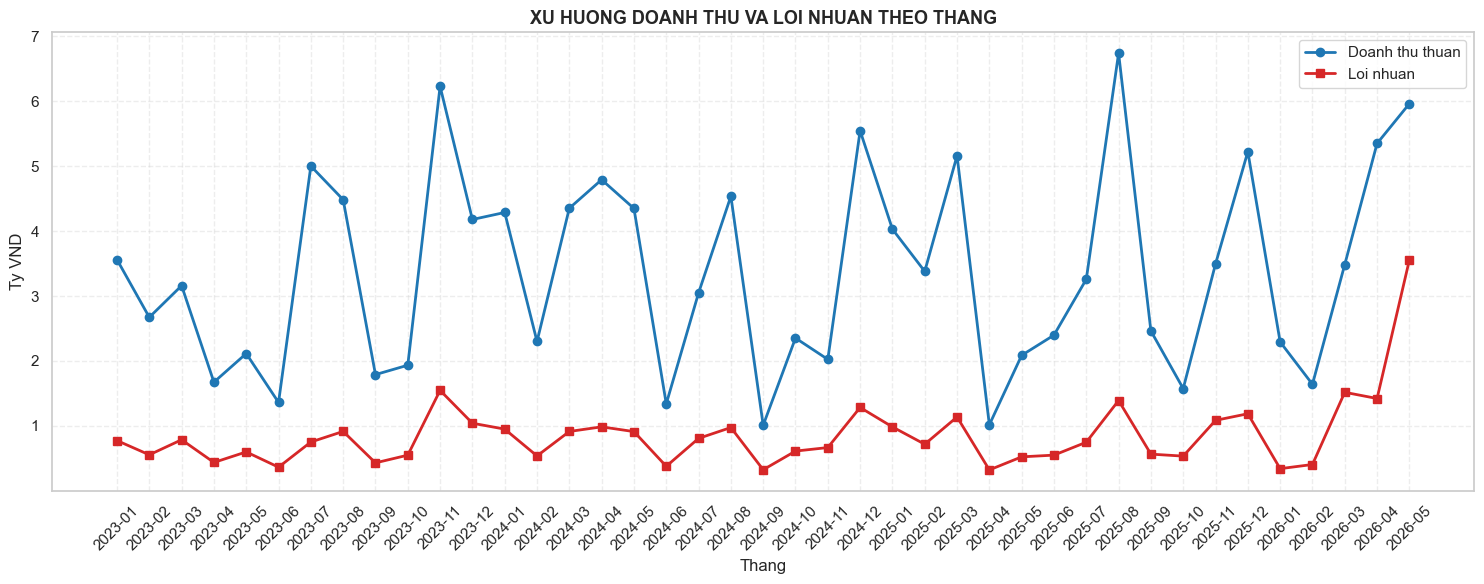

,Nam,Thang,Doanh thu thuan,Loi nhuan,Bien loi nhuan
0,2023,1,"3,560,249,002.00","775,218,999.00",0.22
1,2023,2,"2,672,415,444.00","555,770,626.00",0.21
2,2023,3,"3,159,237,356.00","787,712,617.00",0.25
3,2023,4,"1,673,823,152.00","438,235,667.00",0.26
4,2023,5,"2,114,582,932.00","600,443,581.00",0.28
5,2023,6,"1,362,131,664.00","365,537,010.00",0.27
6,2023,7,"5,000,000,000.00","752,809,366.84",0.15
7,2023,8,"4,482,159,402.00","915,812,640.00",0.20
8,2023,9,"1,790,356,757.00","432,003,927.00",0.24
9,2023,10,"1,934,909,127.96","550,567,329.55",0.28


In [4]:
xu_huong_thang = theo_thang.sort_values(["Nam", "Thang"]).copy()
xu_huong_thang["Ky"] = xu_huong_thang["Nam"].astype(str) + "-" + xu_huong_thang["Thang"].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(xu_huong_thang["Ky"], dinh_dang_ty_vnd(xu_huong_thang["Doanh thu thuan"]), color="#1F77B4", marker="o", linewidth=2, label="Doanh thu thuan")
ax.plot(xu_huong_thang["Ky"], dinh_dang_ty_vnd(xu_huong_thang["Loi nhuan"]), color="#D62728", marker="s", linewidth=2, label="Loi nhuan")
ax.set_title("XU HUONG DOANH THU VA LOI NHUAN THEO THANG", fontsize=13, fontweight="bold")
ax.set_xlabel("Thang")
ax.set_ylabel("Ty VND")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()

display(xu_huong_thang[["Nam", "Thang", "Doanh thu thuan", "Loi nhuan", "Bien loi nhuan"]])

# 4. Co cau doanh thu theo kenh ban hang

Phan nay xem kenh nao dong gop doanh thu/lai nhuan chinh, va co cau kenh thay doi nhu the nao sau tai cau truc.

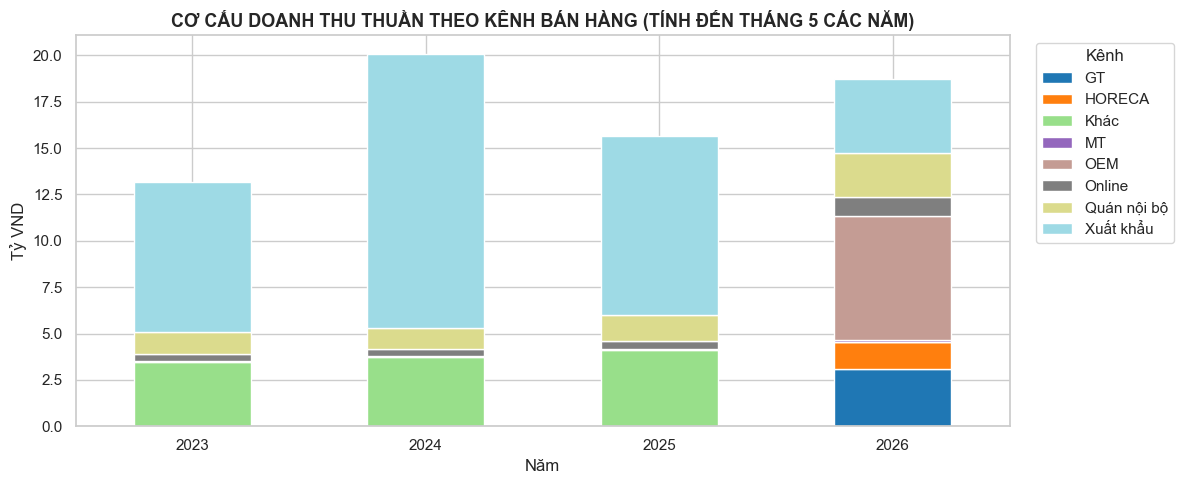

,Nam,Kenh,Doanh_thu,Loi_nhuan,So_dong,Bien_loi_nhuan
4,2023,Xuất khẩu,"8,080,718,700.00","1,427,887,099.00",22,0.18
0,2023,Khác,"3,491,003,321.00","1,165,863,557.00",1478,0.33
3,2023,Quán nội bộ,"1,230,219,660.00","420,668,155.00",530,0.34
2,2023,Online,"337,656,105.00","125,081,837.00",1789,0.37
1,2023,MT,"40,710,100.00","17,880,842.00",33,0.44
9,2024,Xuất khẩu,"14,754,889,200.00","2,587,112,774.00",43,0.18
5,2024,Khác,"3,734,104,724.00","1,152,575,288.00",1493,0.31
8,2024,Quán nội bộ,"1,178,086,190.00","409,754,268.00",467,0.35
7,2024,Online,"369,247,351.00","135,885,924.00",1799,0.37
6,2024,MT,"37,960,000.00","19,242,705.00",23,0.51


In [5]:
du_lieu_ytd = du_lieu_ban_hang[du_lieu_ban_hang["Ngay chung tu"].dt.month <= 5].copy()
doanh_thu_theo_kenh = (
    du_lieu_ytd.groupby(["Nam", "Kenh"], dropna=False)
    .agg(
        Doanh_thu=("Doanh thu thuan", "sum"),
        Loi_nhuan=("Loi nhuan", "sum"),
        So_dong=("Doanh thu thuan", "size"),
    )
    .reset_index()
)
doanh_thu_theo_kenh["Bien_loi_nhuan"] = doanh_thu_theo_kenh["Loi_nhuan"] / doanh_thu_theo_kenh["Doanh_thu"]
bang_cheo_kenh = doanh_thu_theo_kenh.pivot(index="Nam", columns="Kenh", values="Doanh_thu").fillna(0)

(bang_cheo_kenh / 1e9).plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab20")
plt.title("CƠ CẤU DOANH THU THUẦN THEO KÊNH BÁN HÀNG (TÍNH ĐẾN THÁNG 5 CÁC NĂM)", fontsize=13, fontweight="bold")
plt.xlabel("Năm")
plt.ylabel("Tỷ VND")
plt.xticks(rotation=0)
plt.legend(title="Kênh", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(doanh_thu_theo_kenh.sort_values(["Nam", "Doanh_thu"], ascending=[True, False]))

# 5. Co cau theo nhom san pham

Phan nay xem nhom san pham nao tao doanh thu, loi nhuan va bien loi nhuan tot nhat theo nam/quy.

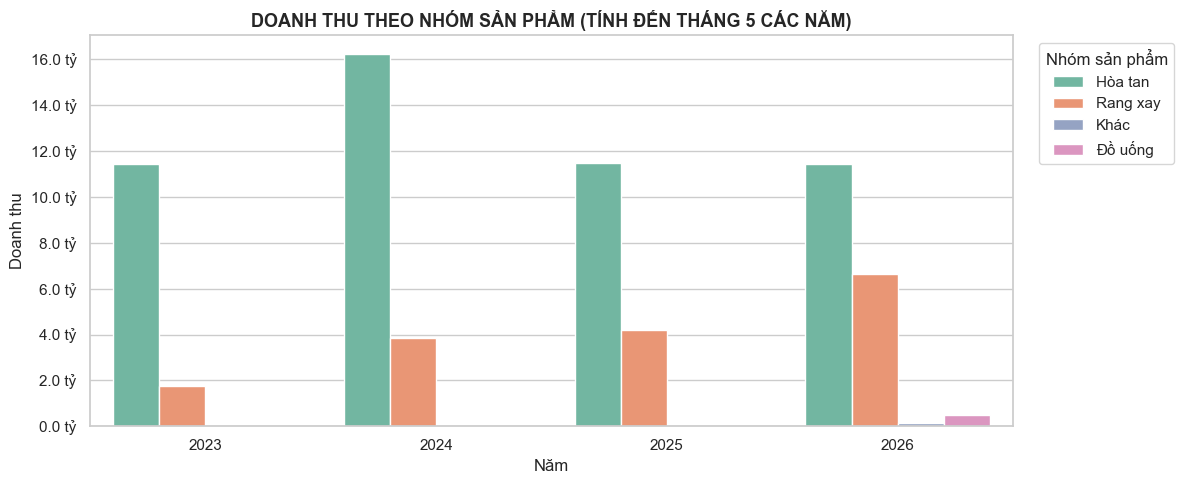

,Nam,Nhom san pham,Doanh_thu,Loi_nhuan,So_luong,So_san_pham,Bien_loi_nhuan
0,2023,Hòa tan,"11,421,815,898.00","2,762,788,446.00","239,270.50",66,0.24
1,2023,Rang xay,"1,758,491,988.00","394,593,044.00","9,003.00",32,0.22
2,2024,Hòa tan,"16,232,975,738.00","3,465,020,762.00","751,507.00",37,0.21
3,2024,Rang xay,"3,841,311,727.00","839,550,197.00","20,135.00",34,0.22
4,2025,Hòa tan,"11,468,032,561.00","2,749,655,317.00","796,717.00",36,0.24
5,2025,Rang xay,"4,203,880,372.44","940,617,300.00","23,935.55",40,0.22
6,2026,Hòa tan,"11,447,043,275.87","5,004,146,873.87","416,900.00",35,0.44
8,2026,Rang xay,"6,619,883,339.07","2,121,774,468.07","35,233.00",53,0.32
9,2026,Đồ uống,"502,592,860.99","81,789,412.99","15,635.00",146,0.16
7,2026,Khác,"158,262,793.44","36,512,736.44",251.00,8,0.23


In [6]:
du_lieu_ytd = du_lieu_ban_hang[du_lieu_ban_hang["Ngay chung tu"].dt.month <= 5].copy()
san_pham_nam = (
    du_lieu_ytd.groupby(["Nam", "Nhom san pham"], dropna=False)
    .agg(
        Doanh_thu=("Doanh thu thuan", "sum"),
        Loi_nhuan=("Loi nhuan", "sum"),
        So_luong=("So luong", "sum"),
        So_san_pham=("Ma san pham", "nunique"),
    )
    .reset_index()
)
san_pham_nam["Bien_loi_nhuan"] = san_pham_nam["Loi_nhuan"] / san_pham_nam["Doanh_thu"]

plt.figure(figsize=(12, 5))
sns.barplot(data=san_pham_nam, x="Nam", y="Doanh_thu", hue="Nhom san pham")
plt.title("DOANH THU THEO NHÓM SẢN PHẨM (TÍNH ĐẾN THÁNG 5 CÁC NĂM)", fontsize=13, fontweight="bold")
plt.xlabel("Năm")
plt.ylabel("Doanh thu")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x/1e9:,.1f} tỷ"))
plt.legend(title="Nhóm sản phẩm", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


display(san_pham_nam.sort_values(["Nam", "Doanh_thu"], ascending=[True, False]))

# 6. Phan tich khach hang va Pareto

Phan nay xac dinh nhom khach hang dong gop doanh thu chinh, dong thoi xem muc do phu thuoc vao cac nhom khach hang lon.

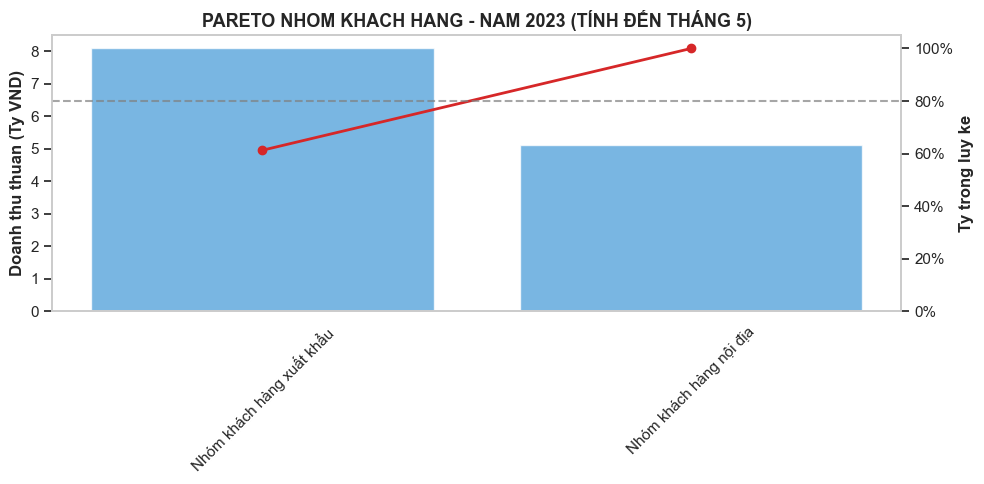

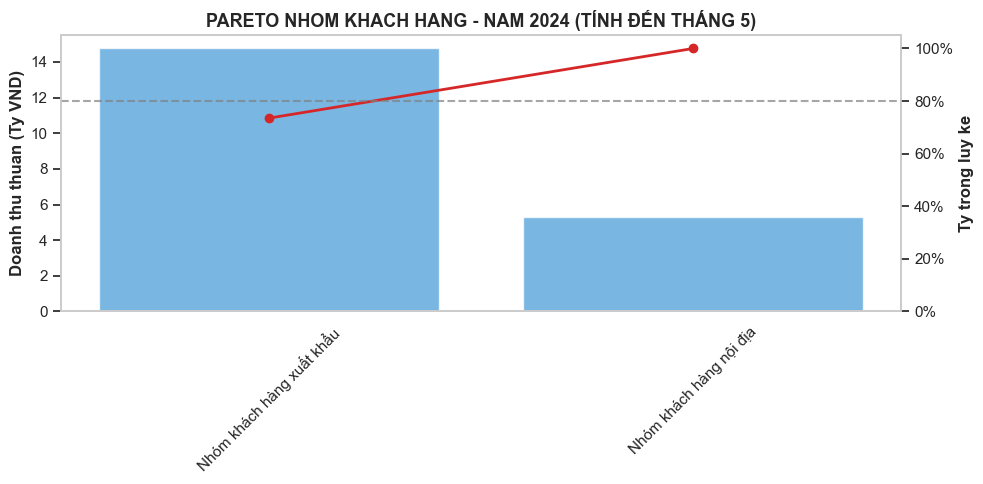

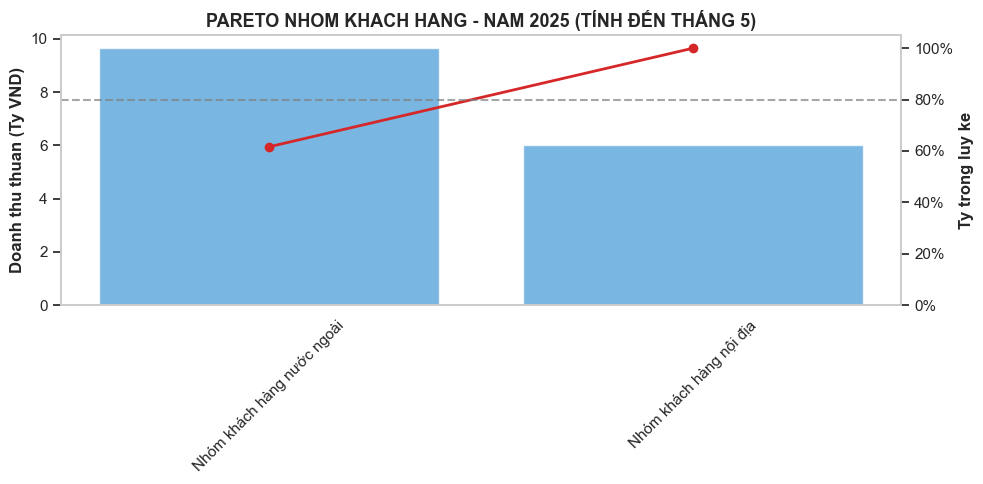

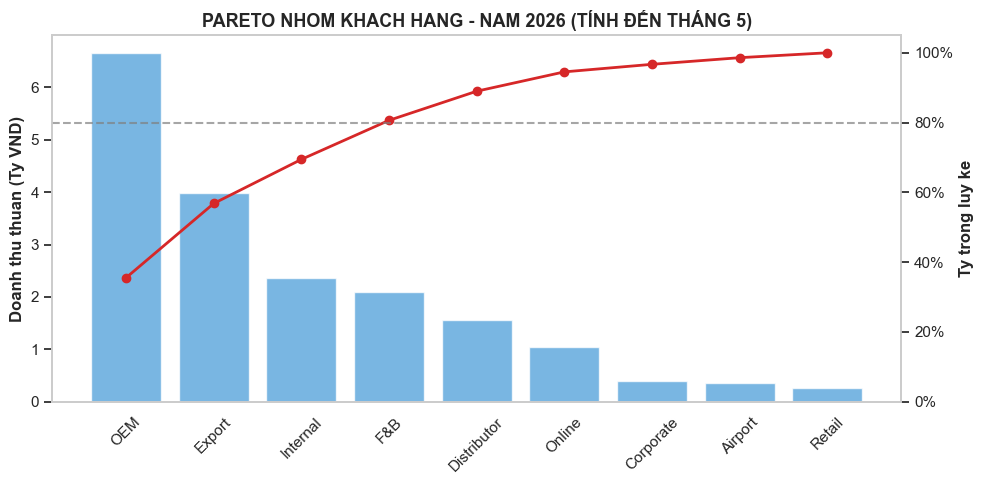

,Nam,Nhom khach hang,Doanh_thu_thuan,Ty trong,Ty trong luy ke
0,2023,Nhóm khách hàng xuất khẩu,"8,080,718,700.00",0.61,0.61
1,2023,Nhóm khách hàng nội địa,"5,099,589,186.00",0.39,1.00
2,2024,Nhóm khách hàng xuất khẩu,"14,754,889,200.00",0.74,0.74
3,2024,Nhóm khách hàng nội địa,"5,319,398,265.00",0.26,1.00
4,2025,Nhóm khách hàng nước ngoài,"9,654,217,623.00",0.62,0.62
5,2025,Nhóm khách hàng nội địa,"6,017,695,310.44",0.38,1.00
6,2026,OEM,"6,657,678,584.30",0.36,0.36
7,2026,Export,"3,985,215,000.00",0.21,0.57
8,2026,Internal,"2,365,400,953.99",0.13,0.69
9,2026,F&B,"2,095,455,659.41",0.11,0.81


In [7]:
du_lieu_ytd = du_lieu_ban_hang[du_lieu_ban_hang["Ngay chung tu"].dt.month <= 5].copy()
nhom_khach_hang_nam = (
    du_lieu_ytd.groupby(["Nam", "Nhom khach hang"], dropna=False)
    .agg(Doanh_thu_thuan=("Doanh thu thuan", "sum"))
    .reset_index()
)

danh_sach_pareto_ytd = []

for nam, bang_nam in nhom_khach_hang_nam.groupby("Nam"):
    bang_nam = bang_nam.sort_values("Doanh_thu_thuan", ascending=False).copy()
    tong_doanh_thu_nam = bang_nam["Doanh_thu_thuan"].sum()
    bang_nam["Ty trong"] = bang_nam["Doanh_thu_thuan"] / tong_doanh_thu_nam
    bang_nam["Ty trong luy ke"] = bang_nam["Ty trong"].cumsum()
    
    danh_sach_pareto_ytd.append(bang_nam)
df_pareto_ytd = pd.concat(danh_sach_pareto_ytd, ignore_index=True)

for nam, bang_nam in df_pareto_ytd.groupby("Nam"):
    bang_nam = bang_nam.sort_values("Doanh_thu_thuan", ascending=False)
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(bang_nam["Nhom khach hang"].astype(str), bang_nam["Doanh_thu_thuan"] / 1e9, color="#4C9ED9", alpha=0.75)
    ax1.set_ylabel("Doanh thu thuan (Ty VND)", fontweight="bold")
    ax1.tick_params(axis="x", rotation=45)
    ax1.grid(False)
    
    ax2 = ax1.twinx()
    ax2.plot(bang_nam["Nhom khach hang"].astype(str), bang_nam["Ty trong luy ke"], color="#D62728", marker="o", linewidth=2)
    ax2.axhline(0.8, color="gray", linestyle="--", alpha=0.7)  # Đường ngưỡng 80% Pareto
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("Ty trong luy ke", fontweight="bold")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:.0%}"))
    ax2.grid(False) 

    plt.title(f"PARETO NHOM KHACH HANG - NAM {nam} (TÍNH ĐẾN THÁNG 5)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

display(df_pareto_ytd.sort_values(["Nam", "Doanh_thu_thuan"], ascending=[True, False]))

# 8. Phan tich outlier

Phan nay dung quy tac IQR de nhan dien cac dong co gia tri bat thuong. Outlier khong duoc xoa tu dong; muc tieu la gan co va lap danh sach kiem tra de phan biet don hang lon hop le, tra hang/chiet khau bat thuong, hoac loi nhap lieu.

In [9]:
def chuan_hoa_du_lieu_truoc(df, cac_cot_so, cot_ngay):
    bang_sach = df.copy()
    if cot_ngay in bang_sach.columns:
        bang_sach[cot_ngay] = pd.to_datetime(
            bang_sach[cot_ngay], errors="coerce"
        )

    for cot in cac_cot_so:
        if cot in bang_sach.columns:
            bang_sach[cot] = pd.to_numeric(bang_sach[cot], errors="coerce")
            bang_sach[cot] = bang_sach[cot].replace([np.inf, -np.inf], np.nan)
    return bang_sach


def tinh_nguong_iqr(chuoi_so, he_so=1.5):
    """Tính các thông số phân vị Q1, Q3, IQR dựa trên tập dữ liệu sạch."""
    gia_tri_hop_le = chuoi_so.dropna()
    if len(gia_tri_hop_le) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    q1 = gia_tri_hop_le.quantile(0.25)
    q3 = gia_tri_hop_le.quantile(0.75)
    iqr = q3 - q1
    can_duoi = q1 - he_so * iqr
    can_tren = q3 + he_so * iqr
    return q1, q3, iqr, can_duoi, can_tren


def gan_co_outlier_iqr(bang_du_lieu, cot_gia_tri, cot_nhom=None, he_so=1.5):
    """Gắn cờ nhận diện outlier chi tiết và trích xuất bảng thông số."""
    bang = bang_du_lieu.copy()
    cot_co = f"Co outlier {cot_gia_tri}"
    cot_muc = f"Muc outlier {cot_gia_tri}"

    bang[cot_co] = False
    bang[cot_muc] = "Binh thuong"

    if cot_nhom is None:
        danh_sach_nhom = [("Toan bo", bang.index)]
    else:
        danh_sach_nhom = bang.groupby(cot_nhom, dropna=False).groups.items()

    nguong = []
    for ten_nhom, chi_muc in danh_sach_nhom:
        gia_tri = bang.loc[chi_muc, cot_gia_tri]
        so_dong_hop_le = gia_tri.notna().sum()

        q1, q3, iqr, can_duoi, can_tren = tinh_nguong_iqr(gia_tri, he_so=he_so)

        if so_dong_hop_le > 0:
            mask_thap = gia_tri < can_duoi
            mask_cao = gia_tri > can_tren

            bang.loc[gia_tri[mask_thap | mask_cao].index, cot_co] = True
            bang.loc[gia_tri[mask_thap].index, cot_muc] = "Thap bat thuong"
            bang.loc[gia_tri[mask_cao].index, cot_muc] = "Cao bat thuong"

            so_outlier = int((mask_thap | mask_cao).sum())
        else:
            so_outlier = 0

        nguong.append({
            "Cot phan tich": cot_gia_tri,
            "Nhom": ten_nhom,
            "Tong so dong": len(chi_muc),
            "So dong hop le": so_dong_hop_le,
            "Cận dưới": q1,
            "Cận trên": q3,
            "IQR": iqr,
            "Can duoi": can_duoi,
            "Can tren": can_tren,
            "So outlier": so_outlier,
            "Ty le outlier": (
                so_outlier / so_dong_hop_le if so_dong_hop_le > 0 else np.nan
            ),
        })

    bang_nguong = pd.DataFrame(nguong)
    return bang, bang_nguong


cac_chi_so_outlier = ["Doanh thu thuan", "Loi nhuan", "So luong", "Bien loi nhuan"]
cot_ngay = "Ngay chung tu"

COT_NHOM = None
HE_SO_IQR = 3.0

df_outlier = chuan_hoa_du_lieu_truoc(
    du_lieu_ban_hang, cac_chi_so_outlier, cot_ngay
)

tong_quan_outlier = []
cac_cot_thuc_te = [cot for cot in cac_chi_so_outlier if cot in df_outlier.columns]

for cot in cac_cot_thuc_te:

    df_outlier, bang_nguong = gan_co_outlier_iqr(
        df_outlier, cot, cot_nhom=COT_NHOM, he_so=HE_SO_IQR
    )

    cot_co = f"Co outlier {cot}"
    for _, row in bang_nguong.iterrows():
        dong = row.to_dict()

        if COT_NHOM is None:
            mask_outlier = df_outlier[cot_co]
        else:
            if pd.isna(row["Nhom"]):
                mask_outlier = df_outlier[cot_co] & df_outlier[COT_NHOM].isna()
            else:
                mask_outlier = (
                    df_outlier[cot_co] & (df_outlier[COT_NHOM] == row["Nhom"])
                )

        if cot_ngay in df_outlier.columns:
            ngay_outlier = df_outlier.loc[mask_outlier, cot_ngay]
            dong["Ngay outlier dau tien"] = (
                ngay_outlier.min() if not ngay_outlier.empty else pd.NaT
            )
            dong["Ngay outlier gan nhat"] = (
                ngay_outlier.max() if not ngay_outlier.empty else pd.NaT
            )
        else:
            dong["Ngay outlier dau tien"] = pd.NaT
            dong["Ngay outlier gan nhat"] = pd.NaT

        tong_quan_outlier.append(dong)

tong_quan_outlier = pd.DataFrame(tong_quan_outlier)

cot_hien_thi_outlier = [
    "Cot phan tich",
    "Nhom",
    "Ngay outlier dau tien",
    "Ngay outlier gan nhat",
    "Cận dưới",
    "Cận trên",
    "So dong hop le",
    "So outlier",
    "Ty le outlier",
]
display(tong_quan_outlier[cot_hien_thi_outlier])

,Cot phan tich,Nhom,Ngay outlier dau tien,Ngay outlier gan nhat,Cận dưới,Cận trên,So dong hop le,So outlier,Ty le outlier
0,Doanh thu thuan,Toan bo,2023-01-03,2026-05-28,"52,000.00","1,053,000.00",55050,2740,0.05
1,Loi nhuan,Toan bo,2023-01-03,2026-05-28,"13,996.00","293,657.75",55050,3474,0.06
2,So luong,Toan bo,2023-01-02,2026-05-28,1.00,7.50,55050,3773,0.07
3,Bien loi nhuan,Toan bo,2026-01-03,2026-05-28,0.22,0.48,53157,229,0.00


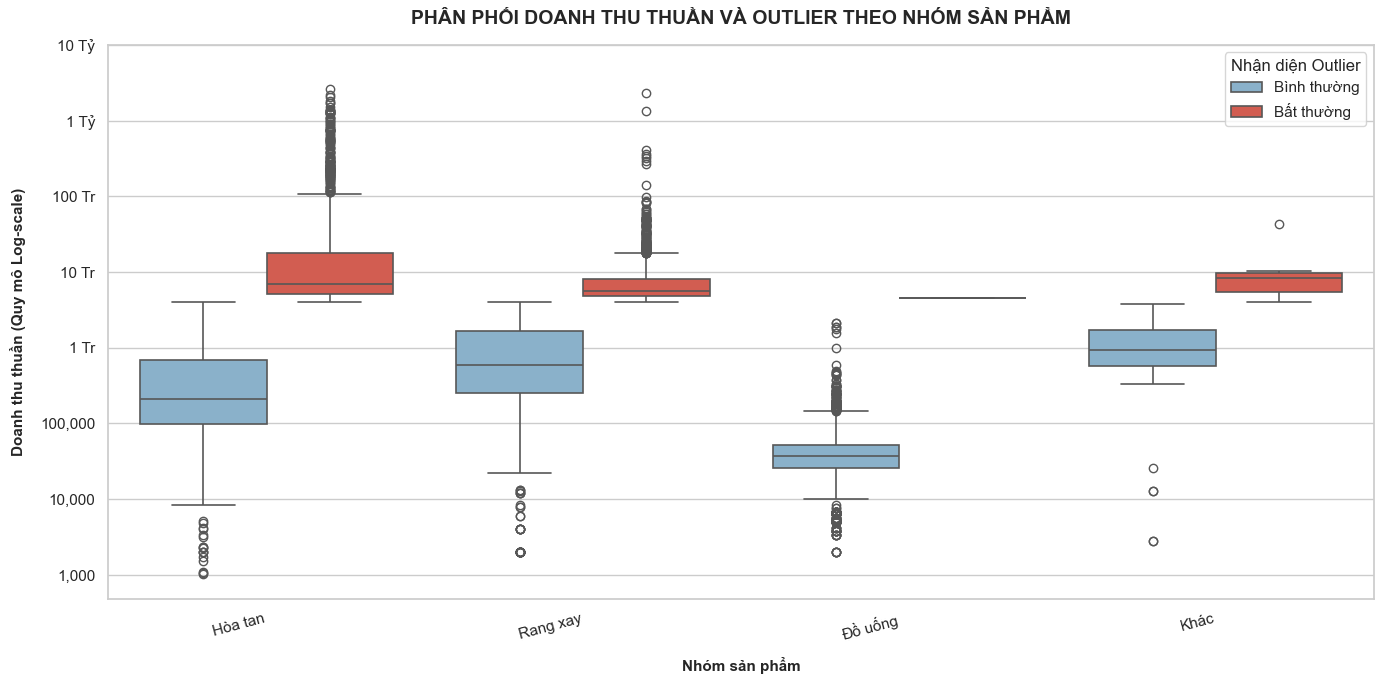

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns

du_lieu_ve = df_outlier[df_outlier["Doanh thu thuan"] > 0].copy()
du_lieu_ve["Doanh thu thuan log10"] = np.log10(du_lieu_ve["Doanh thu thuan"])

du_lieu_ve["Trạng thái"] = du_lieu_ve["Co outlier Doanh thu thuan"].map(
    {False: "Bình thường", True: "Bất thường"}
)

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=du_lieu_ve,
    x="Nhom san pham",
    y="Doanh thu thuan log10",
    hue="Trạng thái",
    palette={
        "Bình thường": "#7FB3D5",
        "Bất thường": "#E74C3C",
    },
    linewidth=1.2,
)
ax = plt.gca()

def log_formatter(x, pos):
    val = 10**x
    if val >= 1e9:
        return f"{val/1e9:,.0f} Tỷ"
    elif val >= 1e6:
        return f"{val/1e6:,.0f} Tr"
    else:
        return f"{val:,.0f}"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_formatter))

y_min = int(np.floor(du_lieu_ve["Doanh thu thuan log10"].min()))
y_max = int(np.ceil(du_lieu_ve["Doanh thu thuan log10"].max()))
ax.set_yticks(range(y_min, y_max + 1))

plt.title(
    "PHÂN PHỐI DOANH THU THUẦN VÀ OUTLIER THEO NHÓM SẢN PHẨM",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Nhóm sản phẩm", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel(
    "Doanh thu thuần (Quy mô Log-scale)",
    fontsize=11,
    fontweight="bold",
    labelpad=10,
)

plt.legend(title="Nhận diện Outlier")
plt.xticks(rotation=15, ha="right")

plt.tight_layout()
plt.show()